# Digit Lab
### Small images. Simple models. Honest evaluation.

**Question:** How well do simple classifiers recognize handwritten digits, and how does noise change their performance?

AI-assisted starter project. The initial code, explanations, and recorded run were prepared with ChatGPT. Follow the learning guide and document your own experiments before presenting personal contributions.

Run the cells in order. Google Colab includes the required scientific Python packages. Local users: install `requirements.txt` first. Results are written into a `results` folder in the current working directory. Library-version changes may change the exact scores.


## 1. Load the data

Each example is an 8 × 8 image flattened into 64 pixel values. Labels are digits 0–9. This is the small UCI digits dataset bundled with scikit-learn, not MNIST. No separate dataset download is needed.


In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
OUT = Path('results')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
digits = load_digits()
X, y = digits.data, digits.target
print(f'{len(y)} images | {X.shape[1]} pixels per image | {len(np.unique(y))} classes')


1797 images | 64 pixels per image | 10 classes


## 2. Reserve a test set

Reserve 20% before training. Stratification keeps class proportions similar. Model selection uses five-fold cross-validation on the remaining 80% only. This random image split does not test generalization to entirely new writers.


Training: 1437 | Test: 360


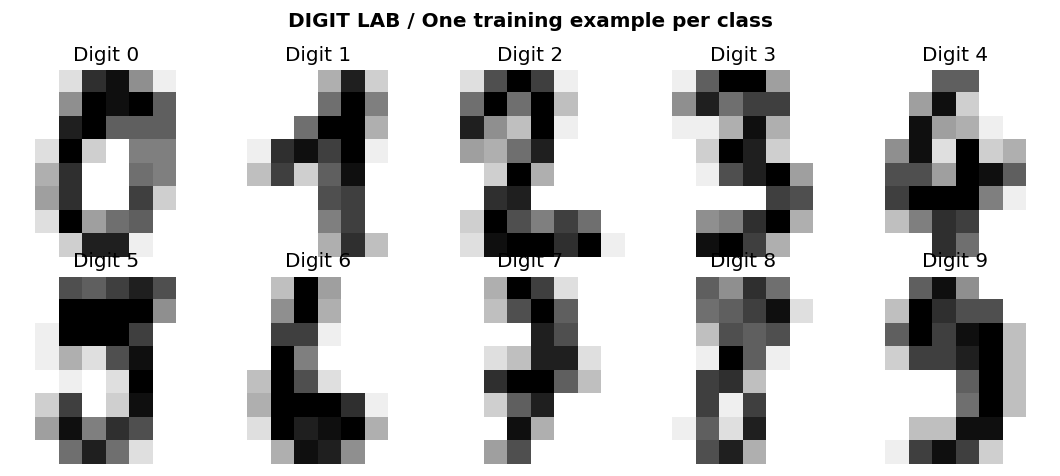

In [2]:
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
assert set(train_idx).isdisjoint(test_idx)
print(f'Training: {len(train_idx)} | Test: {len(test_idx)}')
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for digit, ax in enumerate(axes.flat):
    index = train_idx[np.flatnonzero(y_train == digit)[0]]
    ax.imshow(digits.images[index], cmap='gray_r', vmin=0, vmax=16)
    ax.set_title(f'Digit {digit}')
    ax.axis('off')
fig.suptitle('DIGIT LAB / One training example per class', fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'samples.png', bbox_inches='tight')
plt.show()
plt.close(fig)


## 3. Compare models without using test labels

The dummy baseline always predicts the most frequent training class. Logistic Regression learns linear class boundaries. The RBF SVM can learn nonlinear boundaries. Each learned model includes a scaler inside its pipeline so scaling is fitted independently within each training fold. Hyperparameters below are fixed in advance; choose the model using mean validation accuracy.


In [3]:
models = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000, random_state=SEED)),
    'RBF SVM': make_pipeline(StandardScaler(), SVC(C=3.0, kernel='rbf', gamma='scale')),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
    cv_rows.append({'model': name, 'cv_accuracy_mean': scores.mean(), 'cv_accuracy_std': scores.std()})
cv_table = pd.DataFrame(cv_rows)
selected_name = cv_table.loc[cv_table.cv_accuracy_mean.idxmax(), 'model']
print(cv_table.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('Selected before test evaluation:', selected_name)


              model  cv_accuracy_mean  cv_accuracy_std
     Dummy baseline            0.1009           0.0002
Logistic Regression            0.9680           0.0074
            RBF SVM            0.9812           0.0052
Selected before test evaluation: RBF SVM


## 4. Evaluate the fixed models

Accuracy measures the fraction of correct predictions. Macro F1 gives each digit equal weight when combining precision and recall. Report all predefined models on the same held-out set; do not use these results to retune them. Fold standard deviation is descriptive spread, not a confidence interval.


              model  cv_accuracy_mean  cv_accuracy_std  test_accuracy  test_macro_f1  correct  test_size
     Dummy baseline            0.1009           0.0002         0.1000         0.0182       36        360
Logistic Regression            0.9680           0.0074         0.9722         0.9719      350        360
            RBF SVM            0.9812           0.0052         0.9806         0.9805      353        360


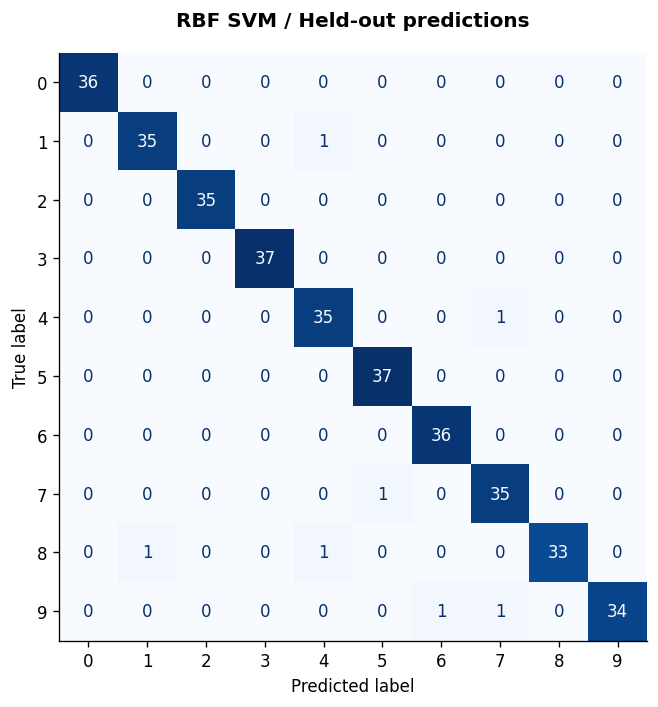

In [4]:
rows, predictions = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    rows.append({'model': name, 'test_accuracy': accuracy_score(y_test, pred),
                 'test_macro_f1': f1_score(y_test, pred, average='macro', zero_division=0),
                 'correct': int(np.sum(y_test == pred)), 'test_size': len(y_test)})
metrics = cv_table.merge(pd.DataFrame(rows), on='model')
metrics.to_csv(OUT / 'metrics.csv', index=False)
print(metrics.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
selected_model = models[selected_name]
selected_pred = predictions[selected_name]
report = classification_report(y_test, selected_pred, output_dict=True, zero_division=0)
(OUT / 'classification_report.json').write_text(json.dumps(report, indent=2))
pd.DataFrame({'dataset_index': test_idx, 'true_digit': y_test,
              'predicted_digit': selected_pred}).to_csv(OUT / 'predictions.csv', index=False)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, selected_pred, display_labels=np.arange(10), ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{selected_name} / Held-out predictions', pad=16, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'confusion_matrix.png', bbox_inches='tight')
plt.show()
plt.close(fig)


## 5. Inspect mistakes

Look at the first twelve errors in test-set order, or all errors if there are fewer. These examples help generate hypotheses about ambiguous shapes; they do not prove why the model failed.


RBF SVM: 7 mistakes out of 360 test images


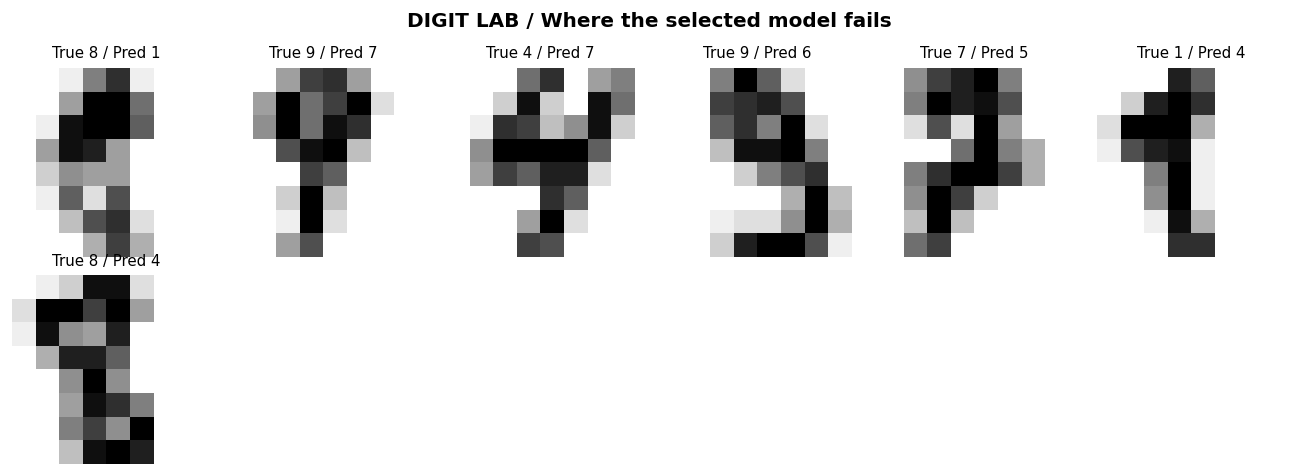

In [5]:
wrong = np.flatnonzero(selected_pred != y_test)
print(f'{selected_name}: {len(wrong)} mistakes out of {len(y_test)} test images')
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax in axes.flat:
    ax.axis('off')
for ax, position in zip(axes.flat, wrong[:12]):
    ax.imshow(X_test[position].reshape(8, 8), cmap='gray_r', vmin=0, vmax=16)
    ax.set_title(f'True {y_test[position]} / Pred {selected_pred[position]}', fontsize=9)
if not len(wrong):
    axes.flat[0].text(0.5, 0.5, 'No mistakes in this split', ha='center')
fig.suptitle('DIGIT LAB / Where the selected model fails', fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'mistakes.png', bbox_inches='tight')
plt.show()
plt.close(fig)


## 6. Stress-test with pixel noise

Keep the trained model fixed. Add zero-mean Gaussian noise with standard deviations 0, 1, 2, 4 and 6 on the original 0–16 pixel scale; clip back into that range. Use ten fixed random draws at each nonzero level. This exploratory stress test measures synthetic corruption, not performance on phone photos or new writers. Do not use it to select hyperparameters.


 noise_sigma  accuracy_mean  accuracy_std  repeats
           0         0.9806        0.0000       10
           1         0.1625        0.0099       10
           2         0.1186        0.0077       10
           4         0.1033        0.0027       10
           6         0.1017        0.0022       10
Saved results to /workspace/scratch/992b03a5fa3b/digit-lab/results


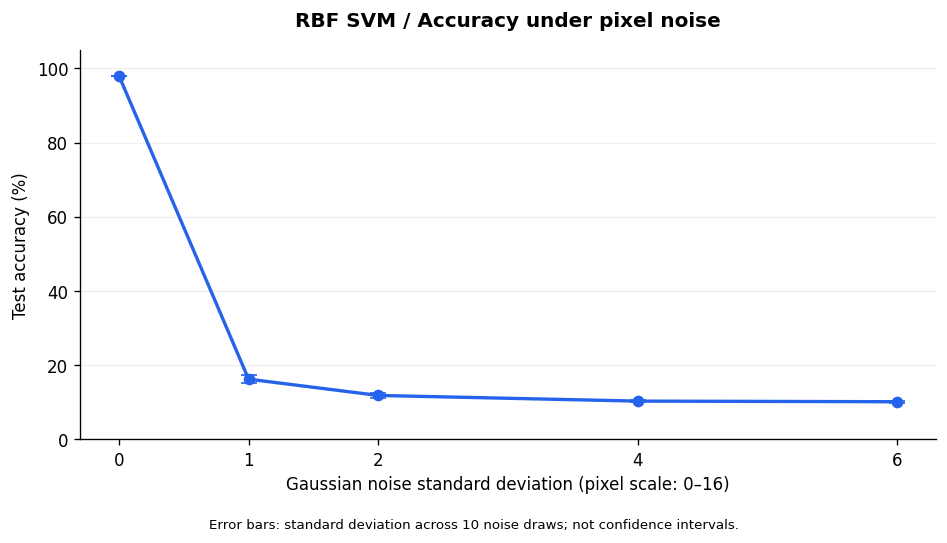

In [6]:
noise_rows = []
for sigma in [0, 1, 2, 4, 6]:
    accuracies = []
    for repeat in range(10):
        rng = np.random.default_rng(SEED + 100 + repeat)
        noisy = np.clip(X_test + rng.normal(0, sigma, X_test.shape), 0, 16)
        accuracies.append(accuracy_score(y_test, selected_model.predict(noisy)))
    noise_rows.append({'noise_sigma': sigma, 'accuracy_mean': float(np.mean(accuracies)),
                       'accuracy_std': float(np.std(accuracies)), 'repeats': 10})
noise_table = pd.DataFrame(noise_rows)
noise_table.to_csv(OUT / 'noise_robustness.csv', index=False)
print(noise_table.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(noise_table.noise_sigma, noise_table.accuracy_mean * 100,
            yerr=noise_table.accuracy_std * 100, fmt='o-', color='#2563eb', linewidth=2, capsize=5)
ax.set(xlabel='Gaussian noise standard deviation (pixel scale: 0–16)',
       ylabel='Test accuracy (%)', ylim=(0, 105), xticks=[0, 1, 2, 4, 6])
ax.grid(axis='y', alpha=0.2)
ax.set_title(f'{selected_name} / Accuracy under pixel noise', fontweight='bold', pad=14)
fig.text(0.5, 0.01, 'Error bars: standard deviation across 10 noise draws; not confidence intervals.', ha='center', fontsize=8)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUT / 'noise_robustness.png', bbox_inches='tight')
plt.show()
plt.close(fig)
metadata = {'seed': SEED, 'train_size': len(train_idx), 'test_size': len(test_idx),
            'selected_model': selected_name, 'selection_rule': 'highest 5-fold training CV accuracy',
            'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scikit_learn': sklearn.__version__,
            'train_indices': train_idx.tolist(), 'test_indices': test_idx.tolist()}
(OUT / 'run_metadata.json').write_text(json.dumps(metadata, indent=2))
print('Saved results to', OUT.resolve())


## Recorded findings
The selected SVM correctly classified 353/360 held-out images (98.06%). At Gaussian noise sigma 1, mean accuracy was 16.25% over ten fixed draws.

A hypothesis is that standardization amplifies noise in low-variance pixels. Compare fixed division by 16 as a follow-up; do not claim a cause has been proven. Further use of this already inspected test set is exploratory.


## 7. Your investigation

The starter experiment is complete. Add your own observations here after running it.

- Which two digits are confused? Inspect their images before proposing an explanation.
- Why does clean-image accuracy fail to describe robustness to corruption?
- Try a K-nearest neighbors model using training cross-validation. Keep any further test-set comparisons explicitly exploratory, or reserve new evaluation data first.
- Record what you changed, the validation result, and whether the evidence supports your hypothesis.

## Sources and limits

Data: [scikit-learn load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), derived from [UCI Optical Recognition of Handwritten Digits](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits), E. Alpaydin and C. Kaynak (1998), [DOI](https://doi.org/10.24432/C50P49), CC BY 4.0.

Only the bundled 1,797-image subset is used and split anew; this is not the original UCI benchmark split. There are no writer identifiers in this experiment. Results do not establish performance on unseen writers or real-world photographs.
